<a href="https://colab.research.google.com/github/ujjwalsoni3000-alt/blackhole-Schwarzschild-/blob/main/blackhole_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Black hole simulation (Schwarzschild)
Units: G = c = M = 1, so the event horizon is at r = 2 and the photon sphere at r = 3.
We use u = 1/r and integrate the orbit equations in the angle φ.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

M = 1.0
r_s = 2 * M

## 1. Light rays bending around the black hole
Photons obey  d²u/dφ² = −u + 3Mu².  Rays with impact parameter b < 3√3 M ≈ 5.196 get captured.

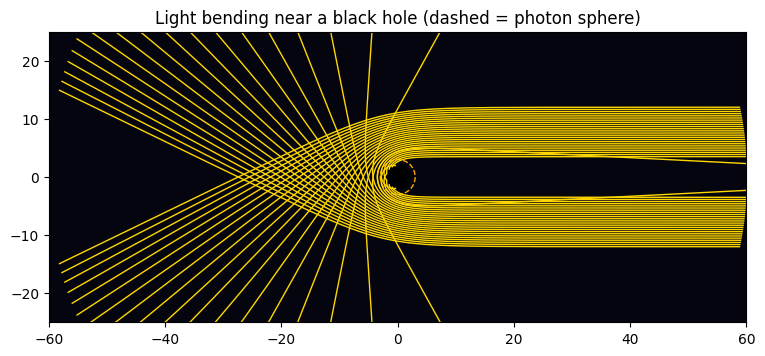

In [ ]:
R0 = 60  # start/stop radius

def trace_ray(b):
    phi0 = np.arcsin(b / R0)
    y0 = [1 / R0, np.cos(phi0) / b]          # u, du/dphi
    f = lambda phi, y: [y[1], -y[0] + 3 * M * y[0] ** 2]
    capture = lambda phi, y: y[0] - 1 / r_s
    capture.terminal = True
    escape = lambda phi, y: y[0] - 0.999 / R0
    escape.terminal = True; escape.direction = -1
    sol = solve_ivp(f, [phi0, 6 * np.pi], y0, events=[capture, escape],
                    max_step=0.01, rtol=1e-9, atol=1e-12)
    phi, u = sol.t, sol.y[0]
    return np.cos(phi) / u, np.sin(phi) / u

fig, ax = plt.subplots(figsize=(9, 6))
for b in np.linspace(3.5, 12, 24):
    x, y = trace_ray(b)
    ax.plot(x, y, 'gold', lw=1); ax.plot(x, -y, 'gold', lw=1)
ax.add_patch(plt.Circle((0, 0), r_s, color='black'))
ax.add_patch(plt.Circle((0, 0), 3 * M, fill=False, ls='--', color='orange', lw=1))
ax.set_xlim(-R0, R0); ax.set_ylim(-25, 25); ax.set_aspect('equal')
ax.set_facecolor('#05050f'); ax.set_title('Light bending near a black hole (dashed = photon sphere)')
plt.show()

## 2. Orbit of a massive particle (perihelion precession)
Massive particles obey  d²u/dφ² = M/L² − u + 3Mu²  where L is angular momentum. The extra 3Mu² term makes the ellipse rotate each orbit.

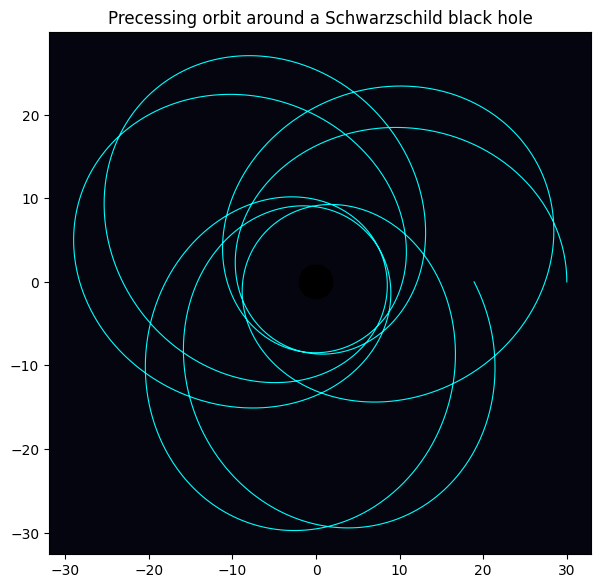

In [ ]:
L = 4.2
f = lambda phi, y: [y[1], M / L**2 - y[0] + 3 * M * y[0] ** 2]
hit = lambda phi, y: y[0] - 1 / r_s
hit.terminal = True
sol = solve_ivp(f, [0, 14 * np.pi], [1 / 30, 0], events=hit, max_step=0.01, rtol=1e-9)
phi, u = sol.t, sol.y[0]
x, y = np.cos(phi) / u, np.sin(phi) / u

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(x, y, lw=0.8, color='cyan')
ax.add_patch(plt.Circle((0, 0), r_s, color='black'))
ax.set_aspect('equal'); ax.set_facecolor('#05050f')
ax.set_title('Precessing orbit around a Schwarzschild black hole')
plt.show()

## Ideas to extend this
- Add a thin accretion disk and ray-trace a full image (one ray per pixel)
- Switch to a spinning (Kerr) black hole
- Animate the particle with `matplotlib.animation.FuncAnimation`